# NASA randomized and recommissioned battery dataset

An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions:

The dataset repository is organized into three main folders, each containing one group of life cycled battery packs. 
Within each folder individual battery packs own their dedicated csv file for continuous data logging, which are named with their respective battery pack number.

The folders are named: 

- regular_alt_batteries: Containing one csv file for each battery pack cycled at the same load level or load range throughout lifetime
- recommissioned_batteries: Containing one csv file for each battery pack cycled at different load levels at varying life stages
- second_life_batteries: Containing one csv file for each second life battery pack cycled at constant current througout the second life 

The columns in each csv file contain the following data with the provided units: 

The following columns contain data throughout the cycling process: 

- start time: [mm:dd:yyyy hh:mm:ss] (start time of each cycle day for each battery pack, in most cases approximately 24h)
- relative time: [s] (the relative time is continuous from the beginning of the entire life cycle to the failure of each battery pack)
- mode: -1 = discharge, 0 = rest, 1 = charge
- voltage charger: [V] (continuous battery pack voltage measurement right after the connection of the battery pack to the charger board)
- temperature battery: [C] (continuous temperature measurement on the battery cell electrode surface)

Those columns only contain data when the respective battery is connected to the load board and performing a discharge mission

- voltage load: [V] (battery pack voltage measured on the load board)
- current load: [A] (discharge current measured on the load board using current sense resistors)
- temperature mosfet: [C] (temperature on the load board mosfets, measured for safety purposes)
- temperature resistor: [C] (temperature on the load board current sense resistor, measured for safety purposes)
- mission type: 0 = reference discharge (constant current at 2.5A), 1 = regular mission

Please cite this dataset using:

```
@misc{2023_alt_dataset_fricke_et_al,
	Author = {Kajetan Fricke and Renato G. Nascimento and Felipe A. C. Viana},
	Doi = {},
	Howpublished = {},
	Month = {July},
	Publisher = {nasa-data@lists.arc.nasa.gov},
	Title = {An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions},
	Url = {},
	Version = {0.0.1},
	Year = {2023}}
```

The corresponding reference entry should look like: 
An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions, v0.0.1, 

### Publications

The following publications out of the PML-UCF research group used/referred to this repository:
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[Prognosis of Li-ion Batteries Under Large Load Variations Using Hybrid Physics-Informed Neural Networks]"
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions]"


## Regular accelerated life test (regular alt batteries folder):

This folder contains the data files from battery packs subject to constant and variable loading conditions, 
where the current range of the latter remains the same throughout the battery life.

The assigned battery packs in this folder are numbered as
follows:

– Constant current:
Those battery packs were subjected to the same load level during discharge missions over their respective life time.

The here provided averaged current levels are approximated, and might vary slightly:

* 9.30A: Battery pack 0.1 and 1.1
* 12.9A: Battery pack 3.1 and 2.2
* 14.3A: Battery pack 2.3 and 5.2
* 16.0A: Battery pack 0.0 and 1.0
* 19.0A: Battery pack 2.0, 3.0 and 2.1

– Variable current:

Those battery packs are subjected to variable current within a discharge cycle.
The current level segments are kept constant for either 40, 60 or 80 seconds before switching to another level.
Both, the amplitude and length of each current level segments was randomly selected to create a pool of different random loading discharge missions.

The here provided averaged current levels are approximated, and might vary slightly:

* 14.3A average (12.9A - 16A range): Battery pack 4.1 and 5.1
* 17.0A average (16A - 19A range): Battery pack 4.0 and 5.0


## Recommissioned batteries (recommissioned batteries folder):

This folder contains the data files from battery packs where the constant loading conditions were changed throughout the battery life. 
The assigned battery packs in this folder are numbered as follows:

– Two life stages:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching an capacity level of approximately 2.2Ah,
and then switched to the second current level until reaching end of life

The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A: Battery pack 3.2
* 14.3A, 16A: Battery pack 5.3
* 16A, 12.9A: Battery pack 0.2 and 3.3
* 16A, 9.30A: Battery pack 1.2 and 2.4

– Three life stages:
Those batteries were subjected to current level switches at approximately 2.2Ah and 2.0Ah of capacity.
The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A, 7.5A: Battery pack 0.3
* 16A, 7.5A, 14.3A: Battery pack 2.5


## Second life batteries (second life batteries folder):

This folder contains the data files from battery packs that consist of battery cells survived from previously cycled battery packs. 
The assigned battery packs in this folder are numbered as follows:

– 2nd life battery packs:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching end of life (EOL).
Survivor cells were then reused and subjected to the second provided current level until reaching EOL

The here provided averaged current levels are approximated, and might vary slightly:

* 16.0A, 9.3A: Battery pack 1.3 (First life battery packs: 0.0 & 1.1)
* 14.3A, 7.5A: Battery pack 3.6 (First life battery packs: 2.3 & 5.2)
* 12.9A, 5.0A: Battery pack 5.4 (First life battery packs: 2.2 & 3.1)

## Machine Learning

### Train-Test-Split

In [1]:
import pandas as pd
import numpy as np

batt_labels = ['battery00','battery01','battery10','battery11','battery20','battery21','battery22',\
              'battery23','battery30','battery31','battery40','battery41','battery50','battery51','battery52',\
              'battery02','battery03','battery12','battery24','battery25','battery32','battery33','battery53']

complete_df = pd.read_csv("data_complete.csv")

np.random.seed(45)#

train_labels = np.random.choice(
    batt_labels,
    size=17,
    replace=False
)

print(train_labels)
test_labels = list(set(batt_labels) - set(train_labels))
print(test_labels)

train_df = pd.DataFrame([])
test_df = pd.DataFrame([])

for label in train_labels:
    train_df = pd.concat([train_df,complete_df[complete_df['batt_label']==label]],axis=0)

for label in test_labels:
    test_df = pd.concat([test_df,complete_df[complete_df['batt_label']==label]],axis=0)

complete_df.head(3)

['battery50' 'battery25' 'battery03' 'battery51' 'battery32' 'battery40'
 'battery10' 'battery24' 'battery12' 'battery53' 'battery23' 'battery30'
 'battery22' 'battery31' 'battery21' 'battery52' 'battery01']
['battery41', 'battery33', 'battery20', 'battery02', 'battery11', 'battery00']


,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,sec_at_low_voltage,integral_high_volt_high_temp,integral_low_volt_high_temp,integral_low_volt_high_discharge,integral_high_temp_high_discharge,integral_low_temp_high_discharge,integral_discharge_squared,R_mOhm,SOH,RUL_EFC
0,battery00,True,7424.475,1.000000,17.149865,0.035283,0.189668,0.278556,0.400463,26.569209,...,567.044,0.0,0.000000,2.660837,0.000000,0.0,3699.325313,218.253968,100.000000,150.232114
1,battery00,False,12219.679,1.992732,32.833935,0.038260,0.190131,0.281978,0.403144,32.363202,...,1351.951,0.0,8043.931358,295.071447,193586.735282,0.0,27459.034333,48.257469,99.782265,149.239381
2,battery00,False,17025.679,2.988488,48.630552,0.041246,0.190595,0.285409,0.405833,35.242986,...,2135.295,0.0,16792.276659,581.592326,401730.220103,0.0,51280.030157,48.681734,99.563867,148.243626


In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aufteilung in 4 Gruppen, so dass in jeder Gruppe ungefähr gleiche Verteilung von
# Strömen und regular/recomissioned test
batt_groups = [['battery01','battery22','battery10','battery50','battery32','battery03'],
               ['battery11','battery23','battery20','battery41','battery53','battery24'],
               ['battery31','battery52','battery30','battery40','battery02','battery25'],
               ['battery00','battery21','battery51','battery12','battery33']]
               

all_mae = {}

def split_test_train(data,train_labels,test_labels):
    train_df = pd.DataFrame([])
    test_df = pd.DataFrame([])

    for label in train_labels:
        train_df = pd.concat([train_df,data[data['batt_label']==label]],axis=0)

    for label in test_labels:
        test_df = pd.concat([test_df,data[data['batt_label']==label]],axis=0)

    return train_df, test_df

def train_gradient_boost(data, train_labels, test_labels, target, feature_set):
    train_df, test_df = split_test_train(data,train_labels,test_labels)
    n_est_list = [10,30,100,300,1000]
    learn_rate_list = [0.15,0.1,0.05,0.02,0.01]
    le = len(n_est_list)
    models = le*[None]
    maes = le * [0.0]
    importance = np.array(len(feature_set)*[0.0])

    y_train = train_df[target]
    y_test = test_df[target]
    
    if len(feature_set) == 1:
        X_train = np.array(train_df[feature_set[0]]).reshape(-1,1)
        X_test = np.array(test_df[feature_set[0]]).reshape(-1,1)
    else:
        X_train = train_df[feature_set]
        X_test = test_df[feature_set]

    for i,n_estimators in enumerate(n_est_list):
        gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=n_estimators,
                        learning_rate=learn_rate_list[i], random_state=42)
        gbrt.fit(X_train, y_train)
        y_test_predict = gbrt.predict(X_test)
        test_mae = mean_absolute_error(y_test,y_test_predict)
        models[i] = gbrt
        maes[i] = test_mae
        #print(f"MAE bei {n_estimators} estimators: {maes[i]}")

    # printe feature importance für modell mit bestem MAE
    best_idx = np.argmin(maes)
    best_model = models[best_idx]
    #print(f"Anzahl Estimators mit bestem MAE: {n_est_list[best_idx]}")

    if len(feature_set) != 1:   
        importance = best_model.feature_importances_
        
    return maes, importance, models

def do_fold_cross_valid(data, target, feature_set):
    sum_maes = np.array(5 * [0.0])
    len_importance = len(feature_set)
    sum_importance = np.array(len_importance*[0.0])
    size = len(batt_groups)

    for i in range(size):
        train_labels = list(set(batt_labels) - set(batt_groups[i]))
        test_labels = batt_groups[i]
        mae, importance, dummy = train_gradient_boost(complete_df, train_labels, test_labels, "SOH", feature_set)
        print(f"MAEs set nr. {i}: {mae}")
        sum_maes += np.array(mae)
        sum_importance += np.array(importance)

    mean_maes = sum_maes / size
    mean_importance = sum_importance / size

    # print mean feature importance averaged over all training sets
    if len_importance != 1:   
        feat_imp = pd.DataFrame({
            "Feature": feature_set,
            "Importance": mean_importance
        })
        
        feat_imp = feat_imp.sort_values(
            by="Importance",
            ascending=False
        )

        print("************Mean Featue Importances averaged over all training sets:**************")
        print(feat_imp)

    
    print("********************Mean MAEs averaged over all test sets:***********************")
    print(f"Mean MAEs: {mean_maes}")
    return mean_maes

def append_mae(name, data, target, features):
    mean_maes = do_fold_cross_valid(complete_df, "SOH", train_features)
    all_mae[name] = {}
    all_mae[name]["MAE @ 10 Estimators"] = mean_maes[0]
    all_mae[name]["MAE @ 30 Estimators"] = mean_maes[1]
    all_mae[name]["MAE @ 100 Estimators"] = mean_maes[2]
    all_mae[name]["MAE @ 300 Estimators"] = mean_maes[3]
    all_mae[name]["MAE @ 1000 Estimators"] = mean_maes[4]

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions(model=None, data=None, feature=None, target=None, title=None):
    ma = data[feature].max()
    x1 = np.linspace(0, ma*1.1, 500)
    fig, axes = plt.subplots(ncols=1, figsize=(10, 4), sharey=True)
    if model != None:
        y_pred = model.predict(x1.reshape(-1,1))
        plt.plot(x1, y_pred, "r-", linewidth=2, label='model')
        plt.title(f"{title} learning_rate={model.learning_rate}, n_estimators={model.n_estimators_}")
        
    sns.scatterplot(data=data, x=feature, y=target, hue='batt_label', legend=False)

    plt.xlabel(feature)
    plt.ylabel(target, rotation=0)
    plt.show()

### Komplettes Feature Set

In [4]:
drop_features = ['batt_label','isRefCycle','SOH','RUL_EFC']
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.926693602245547, 1.5231245418403871, 1.500097679425883, 1.550348786869831, 1.5484200808259063]
MAEs set nr. 1: [1.6745283048317519, 1.031036248609669, 0.9276821221809116, 0.90448111842538, 0.8827056111622132]
MAEs set nr. 2: [1.9216980866895779, 1.142130327197608, 0.9944036104990044, 1.0012268545129714, 1.0060988665483723]
MAEs set nr. 3: [1.9664434100302681, 1.2833599426195579, 1.0676730428766734, 1.023760266910419, 1.004316717011094]
************Mean Featue Importances averaged over all training sets:**************
                              Feature  Importance
36   integral_low_volt_high_discharge    0.482907
28                    Q_norm_at_3.6_V    0.309175
25                        sec_T_30_45    0.058981
1   integral_high_temp_high_discharge    0.049862
31                     sec_C_rate_6_8    0.020246
27                 sec_at_low_voltage    0.012622
23        integral_low_volt_high_temp    0.009849
19                          T_cum_min    0.009713
29      

### Nur Q_norm_at_3.6V Feature

In [5]:
train_features = ['Q_norm_at_3.6_V']
append_mae("Q_norm_at_3.6_V Feature Set", complete_df, "SOH", train_features)
all_mae

MAEs set nr. 0: [1.746762532930028, 1.2609100254146852, 1.2147402558888287, 1.2150657510338791, 1.217827642940664]
MAEs set nr. 1: [1.7203982855328788, 1.1961216183080903, 1.1390500875013618, 1.1336371569058814, 1.1268487779070004]
MAEs set nr. 2: [2.001112875690473, 1.5696250266942118, 1.5137410454953195, 1.5111185165977352, 1.5112669350027041]
MAEs set nr. 3: [1.9407660897431236, 1.3108980329076898, 1.2007648000689717, 1.1899608607457217, 1.1851158749058366]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.85225995 1.33438868 1.26707405 1.26244557 1.26026481]


{'Complete Feature Set': {'MAE @ 10 Estimators': np.float64(1.8723408509492863),
  'MAE @ 30 Estimators': np.float64(1.2449127650668055),
  'MAE @ 100 Estimators': np.float64(1.1224641137456182),
  'MAE @ 300 Estimators': np.float64(1.1199542566796503),
  'MAE @ 1000 Estimators': np.float64(1.1103853188868964)},
 'Q_norm_at_3.6_V Feature Set': {'MAE @ 10 Estimators': np.float64(1.8522599459741258),
  'MAE @ 30 Estimators': np.float64(1.3343886758311692),
  'MAE @ 100 Estimators': np.float64(1.2670740472386204),
  'MAE @ 300 Estimators': np.float64(1.2624455713208045),
  'MAE @ 1000 Estimators': np.float64(1.2602648076890512)}}

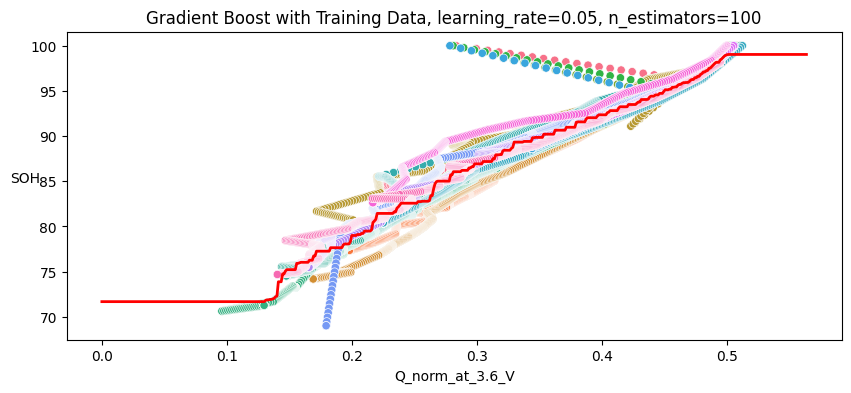

In [6]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['Q_norm_at_3.6_V']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Training Data,")

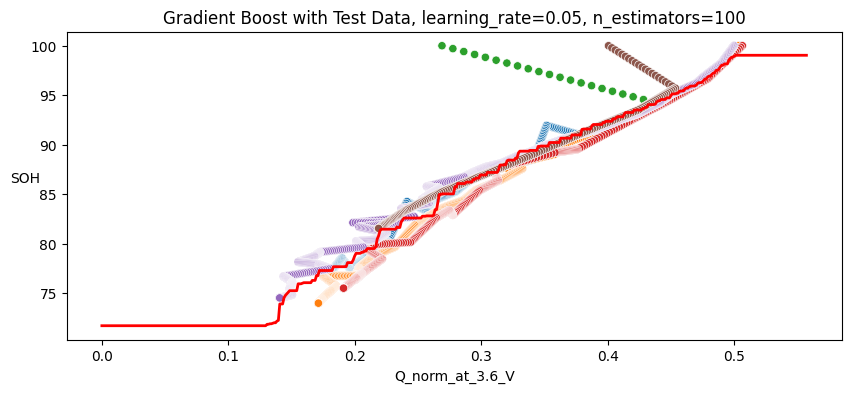

In [7]:
plot_predictions(best_model, test_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Test Data,")

### Feature Set Q_norm

In [8]:
train_features = ['Q_norm_at_3.6_V', 'Q_norm_at_3.7_V','Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
append_mae("Q_norm_at(3.6V, 3.7V, 3.8V, 3.9V) Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.746762532930028, 1.2747979067917576, 1.1536635239219704, 1.1342879889144193, 1.0770195681148387]
MAEs set nr. 1: [1.7414738665287068, 1.226302202298919, 1.069207605522427, 1.0510595272243028, 1.0127444020427436]
MAEs set nr. 2: [2.007917421937316, 1.5812054627061105, 1.4594707190915348, 1.4307470956492712, 1.3290733724508765]
MAEs set nr. 3: [1.9067584008801184, 1.3500050044950112, 1.188647806185996, 1.1507637103957653, 1.0388688113797453]
************Mean Featue Importances averaged over all training sets:**************
           Feature  Importance
0  Q_norm_at_3.6_V    0.924740
1  Q_norm_at_3.7_V    0.048726
3  Q_norm_at_3.9_V    0.014256
2  Q_norm_at_3.8_V    0.012278
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.85072806 1.35807764 1.21774741 1.19171458 1.11442654]


### Feature Set mit Q_norm_at_3.9V, Q_norm_at_3.8V

In [9]:
train_features = ['Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
append_mae("Q_norm_at(3.8V, 3.9V) Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.07456570890644, 1.6862252651945133, 1.6164625454717778, 1.6031169972808716, 1.575264496005812]
MAEs set nr. 1: [2.266024697956703, 1.8869097184494679, 1.7808317442057728, 1.7488031546176228, 1.656790515753976]
MAEs set nr. 2: [2.574169506237743, 2.1784804366161645, 2.091394306987186, 2.0729889756567563, 2.0322642069671586]
MAEs set nr. 3: [2.426649735060249, 1.8936038508709534, 1.7430300213160732, 1.721715488123663, 1.6560968268480076]
************Mean Featue Importances averaged over all training sets:**************
           Feature  Importance
0  Q_norm_at_3.8_V    0.956287
1  Q_norm_at_3.9_V    0.043713
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.33535241 1.91130482 1.80792965 1.78665615 1.73010401]


### Komplettes Feature Set ohne Q_norm

In [10]:
drop_features = ['batt_label','isRefCycle','SOH','RUL_EFC','Q_norm_at_3.6_V','Q_norm_at_3.7_V','Q_norm_at_3.8_V','Q_norm_at_3.9_V']
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set without Q_norm", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.056056171098948, 1.6487771643997893, 1.6603031188373645, 1.6276481715558158, 1.6257056069674132]
MAEs set nr. 1: [1.638409454751787, 1.0512706185341925, 0.9137142397673219, 0.886794382776473, 0.8558754349760436]
MAEs set nr. 2: [1.91152672108738, 1.2104095843313782, 0.993435651638827, 0.9867231764644621, 1.0367111463389087]
MAEs set nr. 3: [1.9731139067460044, 1.2313023121424287, 0.9702551206738985, 0.9190665951536289, 0.9040555793590918]
************Mean Featue Importances averaged over all training sets:**************
                              Feature  Importance
33   integral_low_volt_high_discharge    0.734098
1   integral_high_temp_high_discharge    0.082637
23                        sec_T_30_45    0.073423
28                     sec_C_rate_6_8    0.023472
21        integral_low_volt_high_temp    0.014793
7                       sec_T_over_45    0.013405
18                          T_cum_min    0.011293
25                 sec_at_low_voltage    0.010605
6    

### Feature set with one integral

In [11]:
train_features = ['integral_low_volt_high_discharge']
append_mae("Integral low volt high discharge Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.6584095617276524, 1.1922524963788992, 1.2052101063284142, 1.2111885149461368, 1.2183543882123629]
MAEs set nr. 1: [1.8576475287445477, 1.3308397547504986, 1.2814857704279388, 1.2799897214683378, 1.2845413733297653]
MAEs set nr. 2: [1.9588771948021317, 1.5904435478431023, 1.5655355935457327, 1.5645384446047428, 1.563429806939433]
MAEs set nr. 3: [1.9283292554864713, 1.2403846546748092, 1.0661467880425073, 1.0497735259433194, 1.0419619932661468]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.85081589 1.33848011 1.27959456 1.27637255 1.27707189]


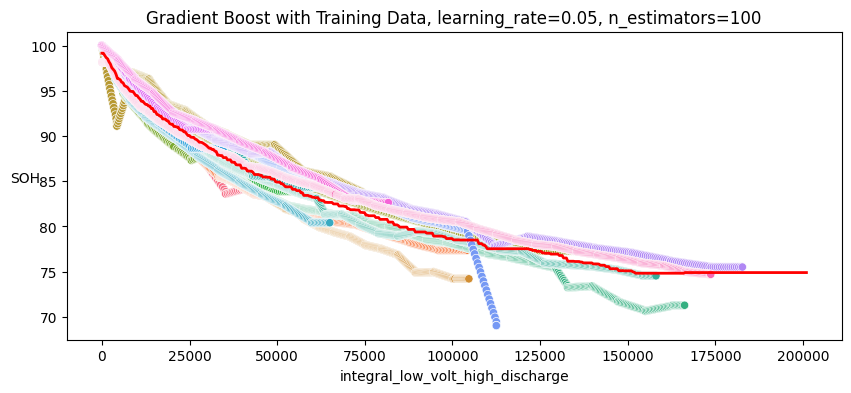

In [12]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_low_volt_high_discharge']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Training Data,")

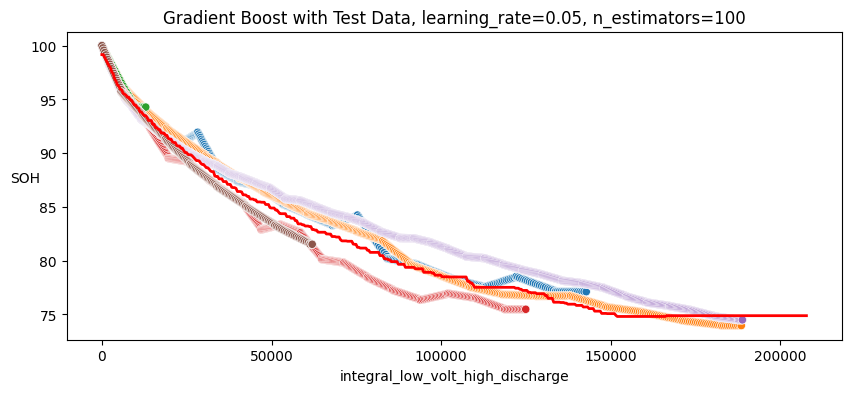

In [13]:
plot_predictions(best_model, test_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Test Data,")

### Feature set only with all integrals

In [14]:
train_features = ['integral_low_volt_high_discharge','integral_low_volt_high_temp','integral_high_temp_high_discharge']
append_mae("All integral features", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.5817584241895304, 1.360629367601987, 1.5515607084423455, 1.573167064380125, 1.5778626943727736]
MAEs set nr. 1: [1.6964636482178688, 1.0890759528603937, 1.0226772024303332, 1.0229230279219221, 0.9970930077727077]
MAEs set nr. 2: [1.9159275718785782, 1.571704070903577, 1.564660797375661, 1.5685040345367678, 1.53892320148803]
MAEs set nr. 3: [1.9320341259281841, 1.2372647109860677, 1.1445254060964645, 1.1426663645098847, 1.1605683828759938]
************Mean Featue Importances averaged over all training sets:**************
                             Feature  Importance
0   integral_low_volt_high_discharge    0.868943
2  integral_high_temp_high_discharge    0.106192
1        integral_low_volt_high_temp    0.024865
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.78154594 1.31466853 1.32085603 1.32681512 1.31861182]


### Feature-Set R_mOhm and C_rate_cycle_max

In [15]:
train_features = ['R_mOhm','C_rate_cycle_max']
append_mae("R_mOhm and C_rate_cycle_max Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [3.578922167371553, 3.052558901411163, 2.757418915246318, 2.697220835573607, 2.6206961404234432]
MAEs set nr. 1: [4.022363977777457, 3.5216477176348837, 3.258951012972326, 3.235971933904269, 3.0432490605267515]
MAEs set nr. 2: [3.642114134064388, 3.256280496555797, 3.0819458084633355, 3.0479358759849684, 3.0281564411279236]
MAEs set nr. 3: [3.3588691539229765, 2.796248124394917, 2.5218649143013416, 2.4368993563322348, 2.3371424125762283]
************Mean Featue Importances averaged over all training sets:**************
            Feature  Importance
0            R_mOhm    0.755245
1  C_rate_cycle_max    0.244755
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [3.65056736 3.15668381 2.90504516 2.854507   2.75731101]


### C Rate Histogram Feature Set

In [16]:
train_features = ['sec_C_rate_0_0.5', 'sec_C_rate_0.5_1', 'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4',\
                  'sec_C_rate_4_6', 'sec_C_rate_6_8', 'sec_C_rate_gt_8']
append_mae("C Rate Histogram Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.326386202349634, 1.636372095709019, 1.423798700207576, 1.3903962308541085, 1.346586989707172]
MAEs set nr. 1: [2.4682964403323844, 1.8040051808196647, 1.4794580333029697, 1.4241917202173786, 1.3099337275177136]
MAEs set nr. 2: [2.0152730395096, 1.2836049102733034, 1.062052907762494, 1.0257648603025293, 1.1663476004284987]
MAEs set nr. 3: [2.158568990573951, 1.6319117313848952, 1.3095681580688308, 1.2164028267209135, 1.1064949124518555]
************Mean Featue Importances averaged over all training sets:**************
            Feature  Importance
2    sec_C_rate_1_2    0.682370
6    sec_C_rate_6_8    0.172947
0  sec_C_rate_0_0.5    0.103690
5    sec_C_rate_4_6    0.030580
4    sec_C_rate_3_4    0.006614
7   sec_C_rate_gt_8    0.002950
3    sec_C_rate_2_3    0.000849
1  sec_C_rate_0.5_1    0.000000
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.24213117 1.58897348 1.31871945 1.26418891 1.23234081]


### T Histogramm Feature Set

In [17]:
train_features = ['sec_T_15_30','sec_T_30_45','sec_T_45_60','sec_T_60_80','sec_T_gt_80']
append_mae("Temperature Histogram Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.8838688591261605, 2.513114196275135, 2.5019536474806356, 2.505111873605837, 2.555858876917458]
MAEs set nr. 1: [2.6414942346129027, 2.3103602347247927, 2.376178546371352, 2.3959677907953103, 2.5571073697798]
MAEs set nr. 2: [1.793410751249392, 1.349201824139214, 1.3181776265503815, 1.3097012206506307, 1.29638718116448]
MAEs set nr. 3: [2.3871327618709413, 1.8368194358702106, 1.74735434554274, 1.7336432309513345, 1.774378351970171]
************Mean Featue Importances averaged over all training sets:**************
       Feature  Importance
1  sec_T_30_45    0.781807
3  sec_T_60_80    0.163557
2  sec_T_45_60    0.026375
0  sec_T_15_30    0.022463
4  sec_T_gt_80    0.005798
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.42647665 2.00237392 1.98591604 1.98610603 2.04593294]


### Feature set t(T > X°C)

In [18]:
train_features = ["sec_T_over_45"]
append_mae("sec_T_over_45 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.784807127174381, 2.83651841630886, 3.0259911000720785, 3.0525653062920344, 3.0824289540740386]
MAEs set nr. 1: [1.8477164825378298, 1.4026506796414433, 1.3168427855758413, 1.311734551115288, 1.3236680071801743]
MAEs set nr. 2: [2.278004657811401, 1.8708548450332436, 1.789266452226731, 1.7836854605138022, 1.7716957008686167]
MAEs set nr. 3: [2.276210779808908, 1.7815674349567676, 1.6817821322548971, 1.675680229131219, 1.6675704464946364]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.29668476 1.97289784 1.95347062 1.95591639 1.96134078]


In [19]:
train_features = ["sec_T_over_40"]
append_mae("sec_T_over_40 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.813219005653303, 2.732372471431121, 2.802438886874657, 2.798782312408695, 2.793304078668922]
MAEs set nr. 1: [2.307599155807966, 1.8355756277219522, 1.738071120668749, 1.7350608308666449, 1.766743612432696]
MAEs set nr. 2: [2.2233937595216267, 1.8715357714793621, 1.8008822181449116, 1.7942247712286794, 1.787200252938624]
MAEs set nr. 3: [2.338090719722586, 1.8731822952814365, 1.796844646182006, 1.7930607786424608, 1.7903959845811082]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.42057566 2.07816654 2.03455922 2.03028217 2.03441098]


In [20]:
train_features = ["sec_T_over_50"]
append_mae("sec_T_over_50 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.5903575237853316, 2.5738302324299225, 2.6797805969128543, 2.6967736215123974, 2.7178136621806783]
MAEs set nr. 1: [3.0050455434209256, 2.763915772080541, 2.7469238674902368, 2.746488926043643, 2.7650605059762032]
MAEs set nr. 2: [2.502386079254501, 2.105260889229036, 2.031618943471536, 2.0237241838162854, 2.018643344173756]
MAEs set nr. 3: [2.477857317078218, 1.9716596101547474, 1.871440691818251, 1.867523017028752, 1.8718616558834003]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.64391162 2.35366663 2.33244102 2.33362744 2.34334479]


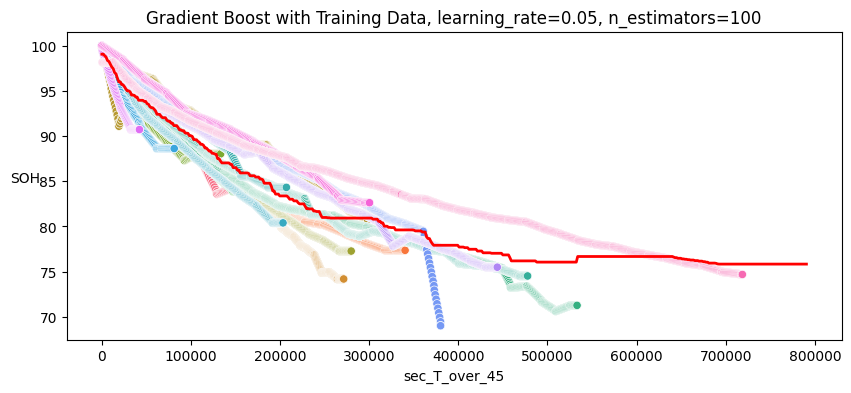

In [21]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['sec_T_over_45']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'sec_T_over_45', "SOH", "Gradient Boost with Training Data,")

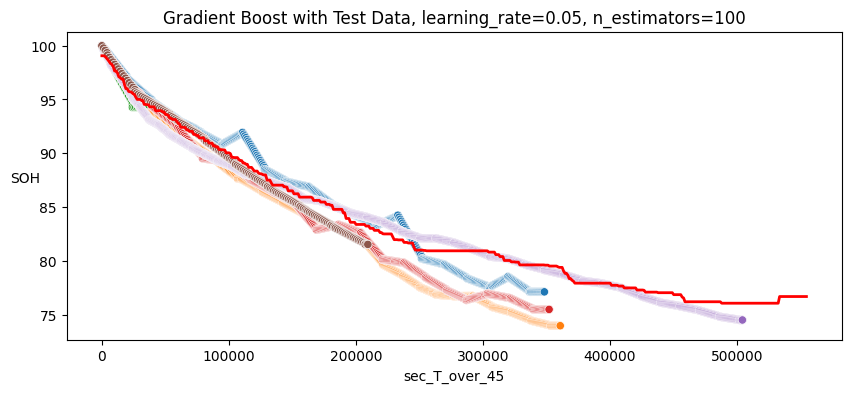

In [22]:
plot_predictions(best_model, test_df, 'sec_T_over_45', "SOH", "Gradient Boost with Test Data,")

### Selbstdefiniertes 'Power Feature Set'

In [23]:
train_features = ['integral_low_volt_high_discharge', 'sec_T_over_45', 'R_mOhm', 'C_rate_cycle_max', 'sec_C_rate_0_0.5', 'sec_C_rate_0.5_1',\
                  'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4', 'sec_C_rate_4_6', 'sec_C_rate_6_8', 'sec_C_rate_gt_8']
append_mae("Power Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.6958816272894808, 1.1895822270564234, 1.0895885950610735, 1.0729986834724932, 1.0592670276162424]
MAEs set nr. 1: [1.8266087561278483, 1.0965605463167112, 0.995116169289045, 1.0029540839558027, 1.0101447010849733]
MAEs set nr. 2: [1.944537716125321, 1.2099442012935637, 1.0173661727912071, 1.0152216268374321, 1.1286340264762837]
MAEs set nr. 3: [1.9472492217897952, 1.357595437508415, 1.0758665937646743, 1.043195391240198, 1.0204624489310612]
************Mean Featue Importances averaged over all training sets:**************
                             Feature  Importance
0   integral_low_volt_high_discharge    0.879214
1                      sec_T_over_45    0.043173
10                    sec_C_rate_6_8    0.040681
6                     sec_C_rate_1_2    0.016933
2                             R_mOhm    0.007482
9                     sec_C_rate_4_6    0.004792
3                   C_rate_cycle_max    0.003387
7                     sec_C_rate_2_3    0.001968
8           

### Zusammenfassung Machine Learning SOH

#### Gradient Boost

In [24]:
all_mae_df = pd.DataFrame(all_mae)
all_mae_df

,Complete Feature Set,Q_norm_at_3.6_V Feature Set,"Q_norm_at(3.6V, 3.7V, 3.8V, 3.9V) Feature Set","Q_norm_at(3.8V, 3.9V) Feature Set",Complete Feature Set without Q_norm,Integral low volt high discharge Feature,All integral features,R_mOhm and C_rate_cycle_max Features,C Rate Histogram Features,Temperature Histogram Features,sec_T_over_45 Feature,sec_T_over_40 Feature,sec_T_over_50 Feature,Power Feature Set
MAE @ 10 Estimators,1.872341,1.852260,1.850728,2.335352,1.894777,1.850816,1.781546,3.650567,2.242131,2.426477,2.296685,2.420576,2.643912,1.853569
MAE @ 30 Estimators,1.244913,1.334389,1.358078,1.911305,1.285440,1.338480,1.314669,3.156684,1.588973,2.002374,1.972898,2.078167,2.353667,1.213421
MAE @ 100 Estimators,1.122464,1.267074,1.217747,1.807930,1.134427,1.279595,1.320856,2.905045,1.318719,1.985916,1.953471,2.034559,2.332441,1.044484
MAE @ 300 Estimators,1.119954,1.262446,1.191715,1.786656,1.105058,1.276373,1.326815,2.854507,1.264189,1.986106,1.955916,2.030282,2.333627,1.033592
MAE @ 1000 Estimators,1.110385,1.260265,1.114427,1.730104,1.105587,1.277072,1.318612,2.757311,1.232341,2.045933,1.961341,2.034411,2.343345,1.054627
